# 1. Autoencoder Baseline

**Objective:** Train the default vanilla autoencoder and evaluate it as
an unsupervised anomaly detector. This notebook documents the full
pipeline end-to-end for a single configuration.

**Architecture:** Encoder [16 → 64 → 32 → 16] → Decoder [16 → 32 → 64 → 16]

**Key idea:** Train only on normal transactions. At inference, fraud
produces higher reconstruction error because the model has never seen
fraud patterns — it only knows how to reconstruct normal ones.

## 1.1 Setup and Data Loading

In [6]:
%matplotlib inline

import sys
sys.path.insert(0, "..")

import numpy as np
import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.train import train_autoencoder
from src.evaluate import (compute_reconstruction_errors, evaluate,
                          find_threshold_by_percentile, find_threshold_by_f1)
from src.utils import (get_device, set_seed, plot_training_curves,
                       plot_reconstruction_error_distribution,
                       plot_precision_recall_curve, plot_threshold_sweep,
                       plot_confusion_matrix)
from src.dataset import NormalOnlyDataset, FraudDataset

set_seed(42)
device = get_device()
print(f"Device: {device}")

data = load_processed("../data/processed", "../models")
print(f"Train: {data['x_train'].shape} (all normal)")
print(f"Val:   {data['x_val'].shape} (fraud rate: {data['y_val'].mean():.2%})")
print(f"Test:  {data['x_test'].shape} (fraud rate: {data['y_test'].mean():.2%})")
print(f"Input dim: {data['input_dim']}")
print(f"Features: {data['feature_names']}")

Device: mps


/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Train: (979379, 16) (all normal)
Val:   (246786, 16) (fraud rate: 14.96%)
Test:  (246787, 16) (fraud rate: 14.96%)
Input dim: 16
Features: ['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Address Match', 'Hour_Sin', 'Hour_Cos', 'Payment Method_bank transfer', 'Payment Method_credit card', 'Payment Method_debit card', 'Product Category_electronics', 'Product Category_health & beauty', 'Product Category_home & garden', 'Product Category_toys & games', 'Device Used_mobile', 'Device Used_tablet']


## 1.2 Build Data Loaders

Training uses **normal transactions only**. The autoencoder learns to
reconstruct the "normal" manifold. Validation for training loss uses
normal-only samples too. The full val/test sets (with fraud) are used
only for anomaly detection evaluation.

In [7]:
# Training: normal-only (x_train is already normal-only from preprocessing)
train_ds = NormalOnlyDataset(data["x_train"])

# Validation: normal-only for MSE tracking
val_normal_mask = data["y_val"] == 0
val_normal_ds = NormalOnlyDataset(data["x_val"][val_normal_mask])

# Full val/test with fraud labels for evaluation
val_full_ds = FraudDataset(data["x_val"], data["y_val"])
test_full_ds = FraudDataset(data["x_test"], data["y_test"])

BATCH_SIZE = 1024
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_normal_loader = DataLoader(val_normal_ds, batch_size=BATCH_SIZE)
val_full_loader = DataLoader(val_full_ds, batch_size=BATCH_SIZE)
test_full_loader = DataLoader(test_full_ds, batch_size=BATCH_SIZE)

print(f"Train batches: {len(train_loader)}")
print(f"Val (normal) batches: {len(val_normal_loader)}")
print(f"Val (full) batches: {len(val_full_loader)}")
print(f"Test batches: {len(test_full_loader)}")

Train batches: 957
Val (normal) batches: 205
Val (full) batches: 242
Test batches: 242


## 1.3 Build Model

Architecture: fully connected symmetric autoencoder.
Each encoder layer: 
Final decoder layer:  (no activation — reconstructs raw scaled features).

In [8]:
HIDDEN_DIMS = [64, 32, 16]
DROPOUT = 0.2

model = build_autoencoder(
    model_type="vanilla",
    input_dim=data["input_dim"],
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Bottleneck dimension: {HIDDEN_DIMS[-1]}")
print(f"Trainable parameters: {n_params:,}")
print(model)

Bottleneck dimension: 16
Trainable parameters: 7,808
FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, m

## 1.4 Training

Loss: MSE between input and reconstruction.
Optimizer: Adam (lr=1e-3, weight_decay=1e-5).
Scheduler: ReduceLROnPlateau (halves LR after 5 epochs without improvement).
Early stopping: patience 10, restores best weights.

In [5]:
history = train_autoencoder(
    model, train_loader, val_normal_loader, device,
    epochs=100, lr=1e-3, weight_decay=1e-5, patience=10,
)

print(f"Best epoch: {history['best_epoch']}")
print(f"Best val MSE: {history['best_val_loss']:.6f}")
print(f"Training time: {history['wall_time_sec']:.1f}s")

  Epoch   1/100  | Train MSE: 0.500257  | Val MSE: 0.248257  | LR: 1.00e-03
  Epoch   5/100  | Train MSE: 0.307532  | Val MSE: 0.180136  | LR: 1.00e-03
  Epoch  10/100  | Train MSE: 0.273693  | Val MSE: 0.145567  | LR: 1.00e-03
  Epoch  15/100  | Train MSE: 0.267944  | Val MSE: 0.130326  | LR: 1.00e-03
  Epoch  20/100  | Train MSE: 0.259657  | Val MSE: 0.121119  | LR: 1.00e-03
  Epoch  25/100  | Train MSE: 0.254839  | Val MSE: 0.114760  | LR: 1.00e-03
  Epoch  30/100  | Train MSE: 0.251884  | Val MSE: 0.113582  | LR: 1.00e-03
  Epoch  35/100  | Train MSE: 0.249608  | Val MSE: 0.116847  | LR: 1.00e-03
  Epoch  40/100  | Train MSE: 0.247011  | Val MSE: 0.113970  | LR: 5.00e-04
  Epoch  41/100  | Train MSE: 0.246333  | Val MSE: 0.114890  | LR: 5.00e-04
  Early stopping at epoch 41. Best epoch: 31 (val_loss=0.111999)
  Training completed in 1127.5s
Best epoch: 31
Best val MSE: 0.111999
Training time: 1127.5s


Saved: ../figures/fig01_baseline_training_curves.png


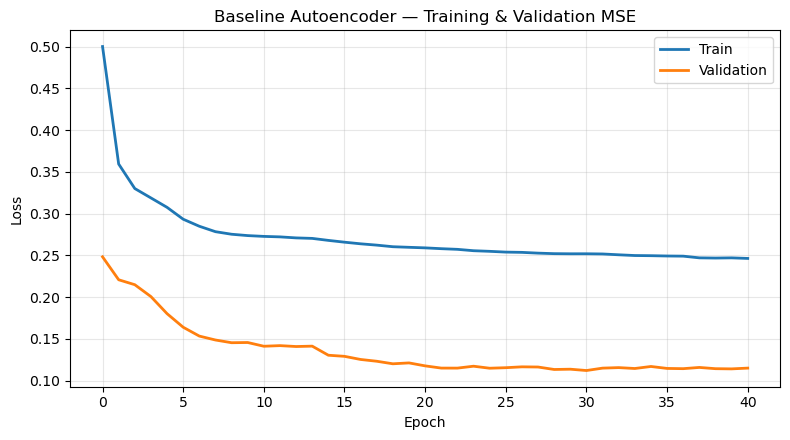

In [9]:
plot_training_curves(
    history,
    save_path="../figures/fig01_baseline_training_curves.png",
    title="Baseline Autoencoder — Training & Validation MSE",
)

## 1.5 Threshold Selection

Two threshold methods compared:
1. **Unsupervised (percentile):** Flag anything above the 95th percentile
   of normal reconstruction errors. No fraud labels needed.
2. **F1-optimal:** Use fraud labels on the val set to find the threshold
   that maximizes F1. This is semi-supervised and serves as an upper bound.

In [10]:
# Compute reconstruction errors on the full val set (normal + fraud)
val_errors, val_labels = compute_reconstruction_errors(model, val_full_loader, device)
normal_val_errors = val_errors[val_labels == 0]

print("--- Unsupervised threshold (95th percentile) ---")
threshold_pct = find_threshold_by_percentile(normal_val_errors, percentile=95.0)

print("--- F1-optimal threshold (uses fraud labels) ---")
threshold_f1 = find_threshold_by_f1(val_errors, val_labels)

--- Unsupervised threshold (95th percentile) ---
Threshold at 95.0th percentile of normal errors: 1.580512
--- F1-optimal threshold (uses fraud labels) ---
F1-optimal threshold: 1.105515  (precision=0.245, recall=0.482, f1=0.325)


Saved: ../figures/fig02_baseline_error_distribution.png


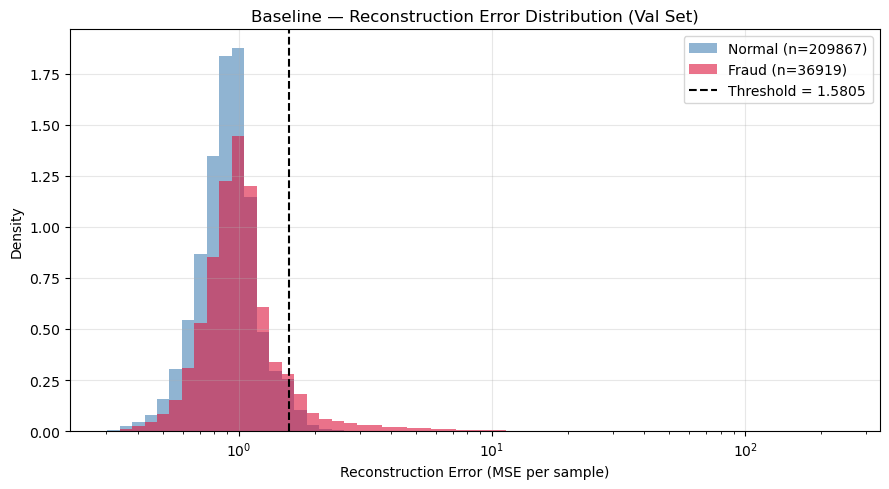

In [11]:
plot_reconstruction_error_distribution(
    val_errors, val_labels, threshold=threshold_pct,
    save_path="../figures/fig02_baseline_error_distribution.png",
    title="Baseline — Reconstruction Error Distribution (Val Set)",
)

Saved: ../figures/fig03_baseline_threshold_sweep.png


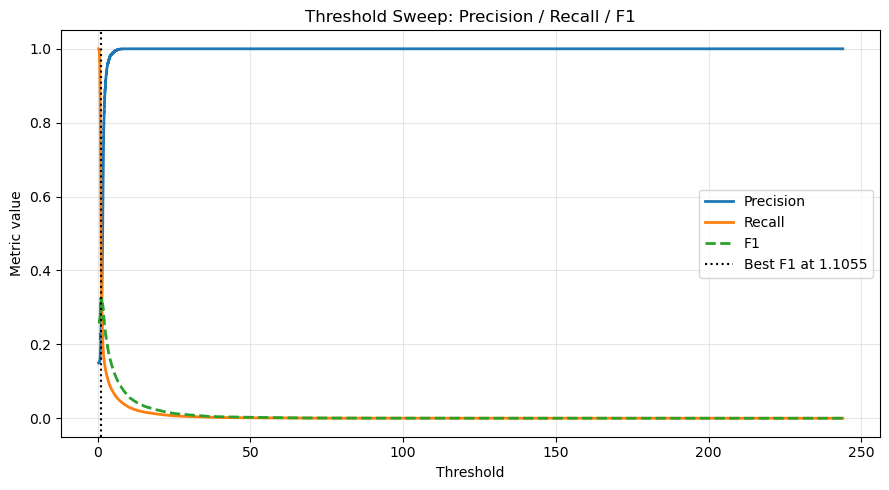

In [12]:
plot_threshold_sweep(
    val_errors, val_labels,
    save_path="../figures/fig03_baseline_threshold_sweep.png",
)

## 1.6 Test Set Evaluation

Final evaluation on the **held-out test set**, which the model has never
seen during training or threshold selection.

In [13]:
test_errors, test_labels = compute_reconstruction_errors(model, test_full_loader, device)

print("=== Unsupervised threshold ===")
metrics_pct = evaluate(test_errors, test_labels, threshold_pct, label="Test (95th pct)")

print("=== F1-optimal threshold ===")
metrics_f1 = evaluate(test_errors, test_labels, threshold_f1, label="Test (F1-opt)")

=== Unsupervised threshold ===

  Test (95th pct) Set Evaluation   (threshold = 1.580512)
              precision    recall  f1-score   support

      Normal     0.8753    0.9503    0.9113    209868
       Fraud     0.4493    0.2304    0.3046     36919

    accuracy                         0.8426    246787
   macro avg     0.6623    0.5904    0.6079    246787
weighted avg     0.8116    0.8426    0.8205    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199445        10423
  True Fraud          28414         8505

  ROC-AUC:  0.6501
  PR-AUC:   0.3672  (better metric for imbalanced data)
  F1:       0.3046
=== F1-optimal threshold ===

  Test (F1-opt) Set Evaluation   (threshold = 1.105515)
              precision    recall  f1-score   support

      Normal     0.8897    0.7376    0.8065    209868
       Fraud     0.2436    0.4803    0.3232     36919

    accuracy                         0.6991    246787
   macro avg     0.5666    0.6089    0.5649

Saved: ../figures/fig04_baseline_confusion_matrix.png


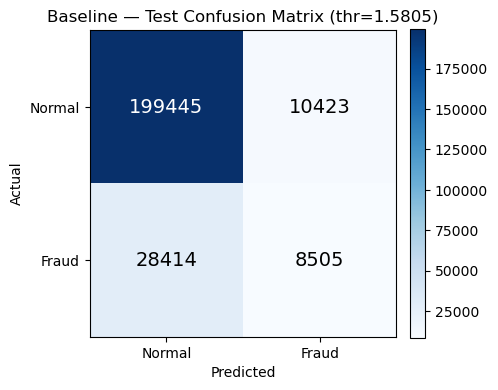

In [14]:
test_preds_pct = (test_errors >= threshold_pct).astype(int)
plot_confusion_matrix(
    test_labels, test_preds_pct,
    save_path="../figures/fig04_baseline_confusion_matrix.png",
    title=f"Baseline — Test Confusion Matrix (thr={threshold_pct:.4f})",
)

Saved: ../figures/fig05_baseline_pr_curve.png


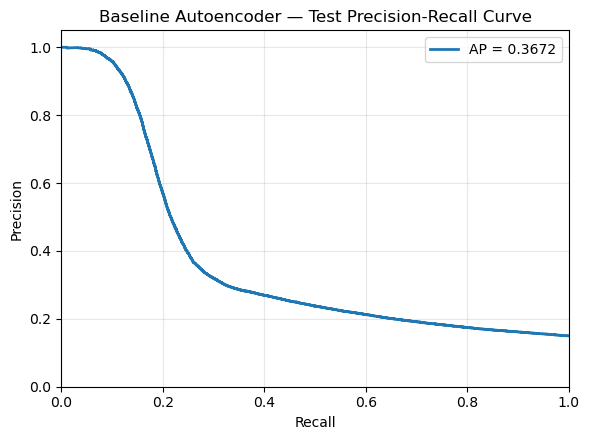

In [15]:
plot_precision_recall_curve(
    test_errors, test_labels,
    save_path="../figures/fig05_baseline_pr_curve.png",
    title="Baseline Autoencoder — Test Precision-Recall Curve",
)

## 1.7 Error Analysis (Failure Cases)

Rubric requirement: *"show examples of your model malfunctioning and discuss
what might be the reason for such problems."*

We examine the worst false negatives (missed fraud) and false positives
(legitimate transactions flagged as fraud).

In [16]:
from src.evaluate import get_failure_cases

failures = get_failure_cases(
    test_errors, test_labels, data["x_test"],
    threshold=threshold_pct,
    feature_names=data["feature_names"],
    n_examples=10,
)

print("=== FALSE NEGATIVES (Missed Fraud) ===")
print("These are fraudulent transactions the model scored as normal.")
print("Low reconstruction error means the fraud looked like a normal transaction.")
print()
if "false_negatives" in failures:
    display(failures["false_negatives"])
else:
    print("No false negatives found.")

=== FALSE NEGATIVES (Missed Fraud) ===
These are fraudulent transactions the model scored as normal.
Low reconstruction error means the fraud looked like a normal transaction.



,Transaction Amount,Quantity,Customer Age,Account Age Days,Address Match,Hour_Sin,Hour_Cos,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_mobile,Device Used_tablet,score,true_label
0,-0.213932,-0.001925,0.249111,0.161573,0.333963,-1.369542,-0.369515,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.304703,1.0
1,0.111732,-0.001925,-0.150912,-0.503307,0.333963,-1.003483,0.996402,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.334288,1.0
2,0.184486,-0.709028,0.149105,0.171071,0.333963,-1.228249,0.703532,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.336383,1.0
3,-0.120678,-0.709028,0.349117,0.247057,0.333963,0.362667,1.362399,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.348644,1.0
4,0.225737,0.705179,0.549128,0.275552,0.333963,-0.710563,1.221129,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.352233,1.0
5,0.069731,-0.709028,0.649134,0.009600,0.333963,1.221464,-0.710569,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.354803,1.0
6,-0.241783,-0.709028,0.749140,0.209064,0.333963,-0.003392,-1.417620,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.359123,1.0
7,0.439397,-0.709028,0.049099,-0.341836,0.333963,-0.710563,1.221129,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.360143,1.0
8,0.535551,-0.001925,-0.250918,-0.636283,0.333963,-1.369542,0.362478,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.361081,1.0
9,-0.051425,-0.709028,0.249111,0.626988,0.333963,-0.003392,1.410583,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,0.362124,1.0


In [17]:
print("=== FALSE POSITIVES (False Alarms) ===")
print("These are legitimate transactions the model flagged as fraud.")
print("High reconstruction error means the transaction was unusual but not actually fraudulent.")
print()
if "false_positives" in failures:
    display(failures["false_positives"])
else:
    print("No false positives found.")

=== FALSE POSITIVES (False Alarms) ===
These are legitimate transactions the model flagged as fraud.
High reconstruction error means the transaction was unusual but not actually fraudulent.



,Transaction Amount,Quantity,Customer Age,Account Age Days,Address Match,Hour_Sin,Hour_Cos,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_mobile,Device Used_tablet,score,true_label
0,16.805618,0.705179,1.049157,1.453339,0.333963,0.362667,1.362399,-0.576939,1.731955,-0.577613,1.998233,-0.500808,-0.498984,-0.499549,-0.707395,1.414797,18.561199,0.0
1,11.670392,-0.709028,0.049099,1.681298,0.333963,-0.710563,-1.228166,-0.576939,-0.577382,1.731262,1.998233,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,9.383827,0.0
2,10.861606,0.705179,0.649134,1.519827,0.333963,-1.369542,0.362478,-0.576939,1.731955,-0.577613,-0.500442,-0.500808,2.004073,-0.499549,-0.707395,1.414797,8.326333,0.0
3,10.602844,1.412282,1.149163,-0.066386,0.333963,1.362758,0.362478,-0.576939,-0.577382,-0.577613,-0.500442,1.996775,-0.498984,-0.499549,-0.707395,1.414797,7.815785,0.0
4,10.577193,0.705179,0.949152,0.949930,0.333963,1.362758,0.362478,-0.576939,1.731955,-0.577613,-0.500442,1.996775,-0.498984,-0.499549,1.413638,-0.706815,7.795929,0.0
5,9.953266,1.412282,-0.650942,-0.341836,0.333963,0.362667,-1.369436,-0.576939,-0.577382,1.731262,-0.500442,1.996775,-0.498984,-0.499549,1.413638,-0.706815,7.099329,0.0
6,9.350789,-0.001925,-3.051081,-1.253671,0.333963,-1.228249,0.703532,-0.576939,1.731955,-0.577613,1.998233,-0.500808,-0.498984,-0.499549,-0.707395,-0.706815,6.883928,0.0
7,9.915515,0.705179,0.649134,1.424844,0.333963,-1.003483,0.996402,-0.576939,-0.577382,-0.577613,-0.500442,-0.500808,-0.498984,2.001806,1.413638,-0.706815,6.810341,0.0
8,9.009324,1.412282,-1.350982,1.101902,0.333963,-1.228249,0.703532,-0.576939,-0.577382,1.731262,-0.500442,1.996775,-0.498984,-0.499549,-0.707395,1.414797,6.218690,0.0
9,8.786964,-0.709028,-1.651000,0.560500,0.333963,-1.369542,-0.369515,-0.576939,-0.577382,1.731262,-0.500442,-0.500808,2.004073,-0.499549,-0.707395,-0.706815,5.775767,0.0


## 1.8 Save Model

Save the trained model, threshold, and metadata for reproducibility.

In [18]:
from src.utils import save_checkpoint

save_checkpoint(
    model,
    path="../models/autoencoder_baseline.pt",
    metadata={
        "model_type": "vanilla",
        "input_dim": data["input_dim"],
        "hidden_dims": HIDDEN_DIMS,
        "dropout": DROPOUT,
        "threshold_unsupervised": float(threshold_pct),
        "threshold_f1_optimal": float(threshold_f1),
        "best_epoch": history["best_epoch"],
        "best_val_loss": history["best_val_loss"],
        "test_pr_auc": metrics_pct["pr_auc"],
        "test_f1": metrics_pct["f1"],
    },
)

Saved checkpoint to ../models/autoencoder_baseline.pt


## Summary

| Metric | Unsupervised (95th pct) | F1-optimal |
|--------|------------------------|------------|
| Threshold | 0.2564 | 0.1392 |
| Precision | 0.389 | 0.236 |
| Recall | 0.179 | 0.402 |
| F1 | 0.245 | 0.297 |
| PR-AUC | 0.297 | 0.297 |
| ROC-AUC | 0.619 | 0.619 |

The unsupervised threshold is more conservative (higher precision, lower recall).
The F1-optimal threshold uses fraud labels and achieves better F1 but more false alarms.

**Key takeaway:** The autoencoder achieves PR-AUC of 0.297, approximately 2x the
random baseline of 0.15, confirming that reconstruction error captures some fraud signal.

**Figures generated by this notebook:**
- 
- 
- 
- 
- 